# EDA: graficos, pruebas estadisticas y regresion

Notebook de demostracion para importar y usar las clases del modulo `scripts`.

In [8]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris

from scripts import (
    GraficosCuantitativos,
    GraficosCualitativos,
    TestEstadisticos,
    RegresionLineal,
    RegresionLogistica,
)

sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

In [9]:
iris = load_iris(as_frame=True)
df = iris.frame.rename(columns={
    "sepal length (cm)": "sepal_length",
    "sepal width (cm)": "sepal_width",
    "petal length (cm)": "petal_length",
    "petal width (cm)": "petal_width",
})
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))
df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 1) Graficos cuantitativos

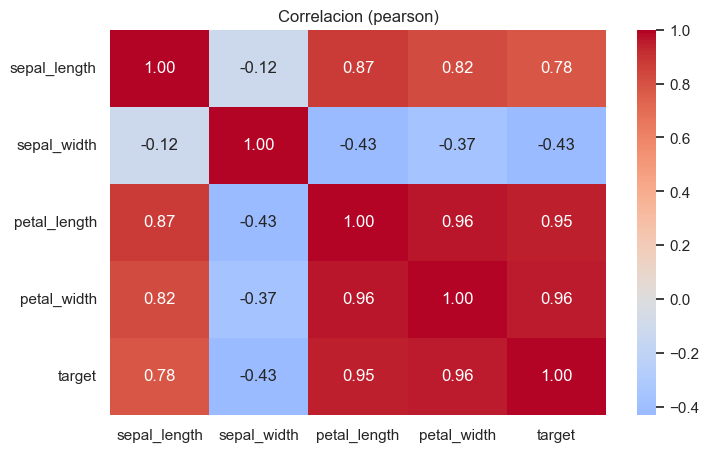

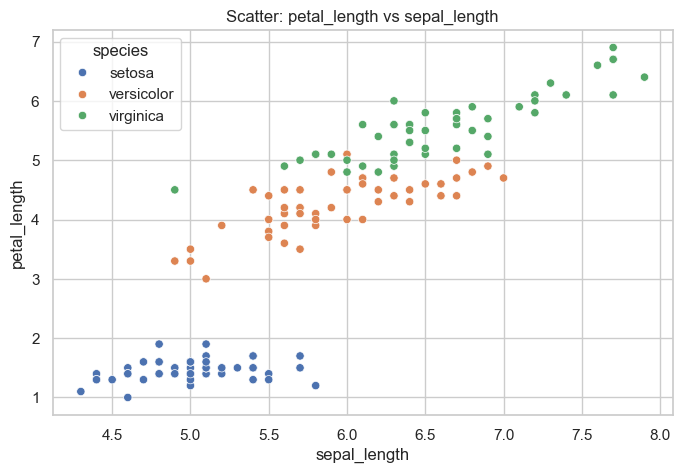

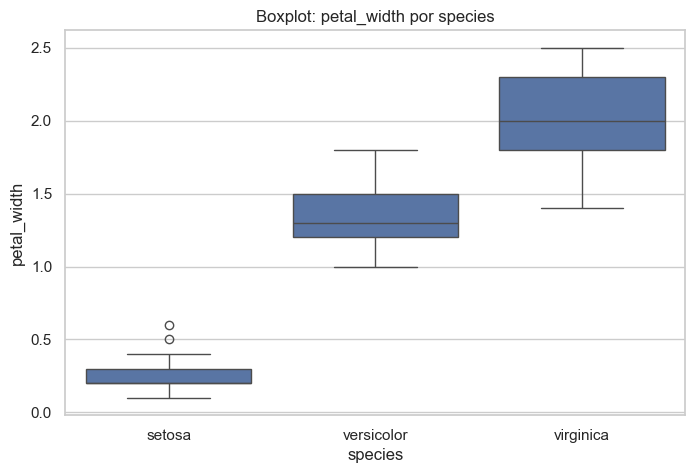

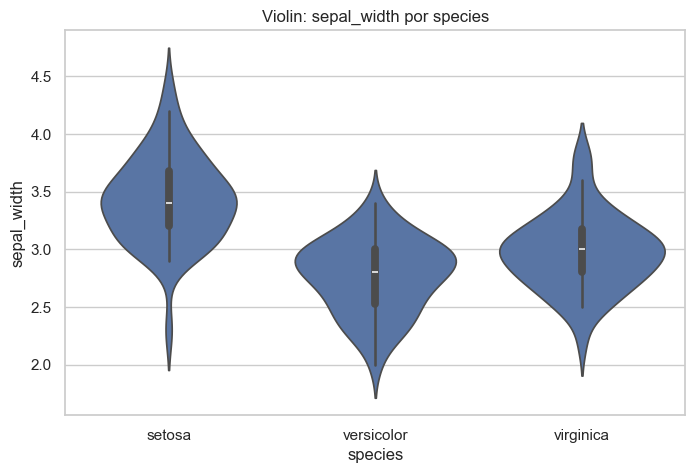

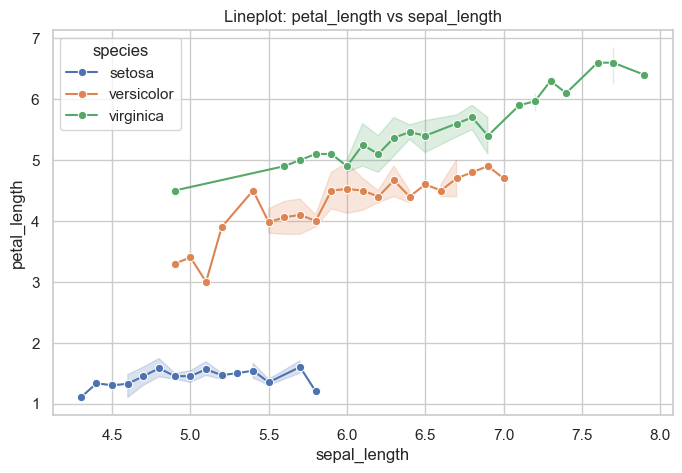

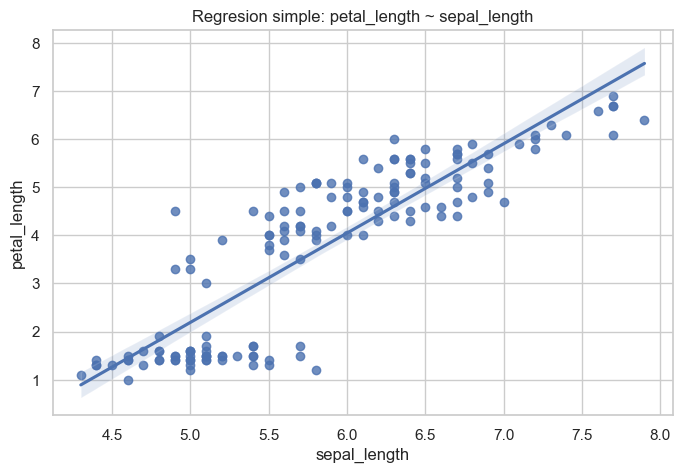

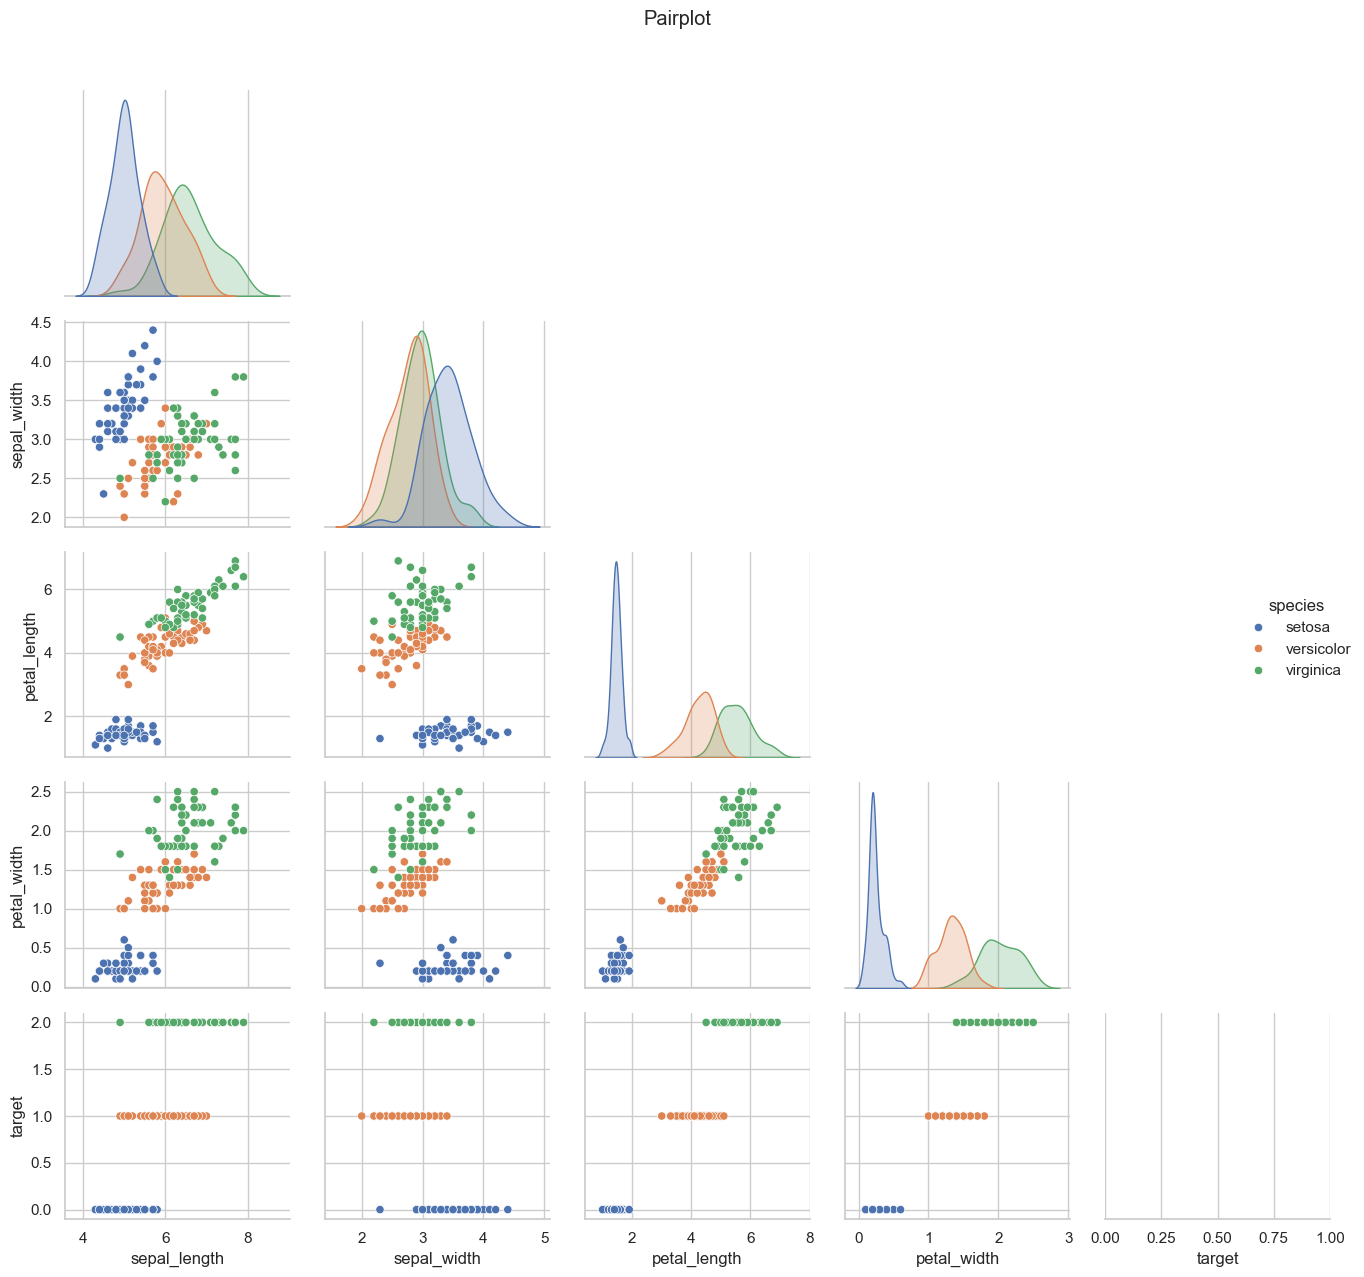

In [10]:
g_cuant = GraficosCuantitativos(df)

g_cuant.heatmap_correlacion()
plt.show()

g_cuant.scatter("sepal_length", "petal_length", hue="species")
plt.show()

g_cuant.boxplot(x="species", y="petal_width")
plt.show()

g_cuant.violin(x="species", y="sepal_width")
plt.show()

g_cuant.lineplot(x="sepal_length", y="petal_length", hue="species")
plt.show()

g_cuant.regplot("sepal_length", "petal_length")
plt.show()

g_cuant.pairplot(hue="species")
plt.show()

## 2) Graficos cualitativos

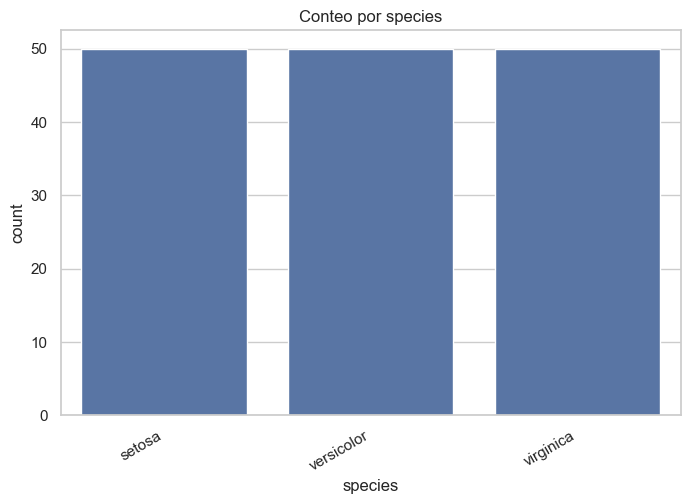

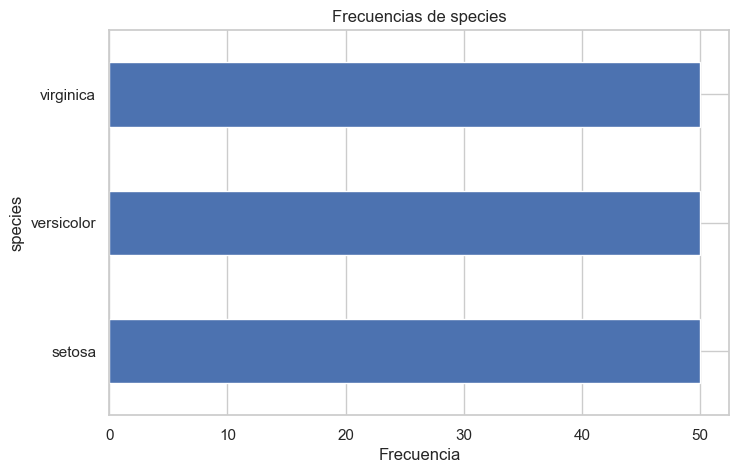

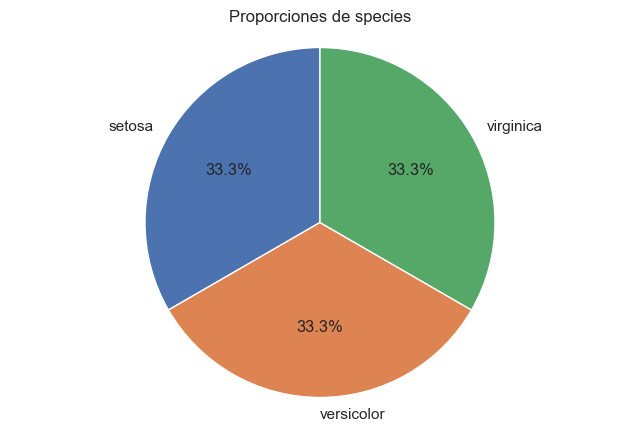

In [11]:
g_cual = GraficosCualitativos(df, cols=["species"])

g_cual.countplot("species")
plt.show()

g_cual.bar_frecuencias("species")
plt.show()

g_cual.pie("species")
plt.show()

## 3) Pruebas estadisticas

In [12]:
tests = TestEstadisticos(df)

print("ANOVA (petal_length por especie):")
display(tests.anova("petal_length", "species"))

print("\nMANOVA:")
display(tests.manova("sepal_length + sepal_width ~ species"))

print("\nt de Student (setosa vs versicolor):")
display(pd.Series(tests.ttest_student(
    "petal_length", "species", "setosa", "versicolor"
)))

df["larga"] = (df["petal_length"] > df["petal_length"].median()).map({True: "si", False: "no"})
print("\nChi-cuadrado (species vs larga):")
chi = tests.chi_cuadrado("species", "larga")
display(pd.Series({k: v for k, v in chi.items() if k not in ("tabla_observada", "tabla_esperada")}))
display(chi["tabla_observada"])

ANOVA (petal_length por especie):


,df,sum_sq,mean_sq,F,PR(>F)
C(species),2.0,437.1028,218.551400,1180.161182,2.856777e-91
Residual,147.0,27.2226,0.185188,NaN,NaN



MANOVA:



t de Student (setosa vs versicolor):


prueba     t independiente (Welch)
grupo_a                     setosa
grupo_b                 versicolor
t                       -39.492719
p_valor                        0.0
media_a                      1.462
media_b                       4.26
dtype: object


Chi-cuadrado (species vs larga):


chi2       1.000000e+02
p_valor    1.928750e-22
gl         2.000000e+00
dtype: float64

larga,no,si
species,,
setosa,50,0
versicolor,25,25
virginica,0,50


## 4) Regresion lineal multiple

                            OLS Regression Results                            
Dep. Variable:           petal_length   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     1410.
Date:                Mon, 25 May 2026   Prob (F-statistic):          6.09e-115
Time:                        19:56:26   Log-Likelihood:                -21.108
No. Observations:                 150   AIC:                             52.22
Df Residuals:                     145   BIC:                             67.27
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

,coef,error_std,t,p_valor,ic_inf,ic_sup
Intercept,-1.634301,0.267829,-6.102035,9.076480e-09,-2.163655,-1.104948
C(species)[T.versicolor],2.170227,0.106570,20.364282,2.273978e-44,1.959595,2.380859
C(species)[T.virginica],3.049112,0.122668,24.856589,3.872008e-54,2.806664,3.291561
sepal_length,0.646310,0.053534,12.072869,1.151112e-23,0.540502,0.752118
sepal_width,-0.040585,0.081130,-0.500248,6.176589e-01,-0.200935,0.119765


R2              0.974938
R2_ajustado     0.974246
AIC            52.215524
BIC            67.268700
RMSE            0.283294
dtype: float64

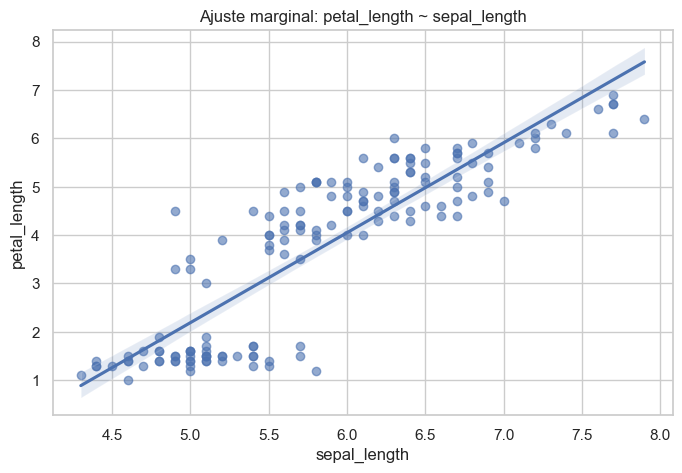

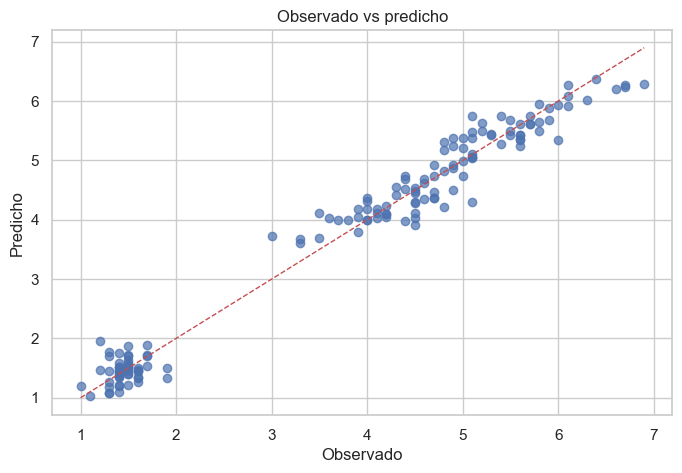

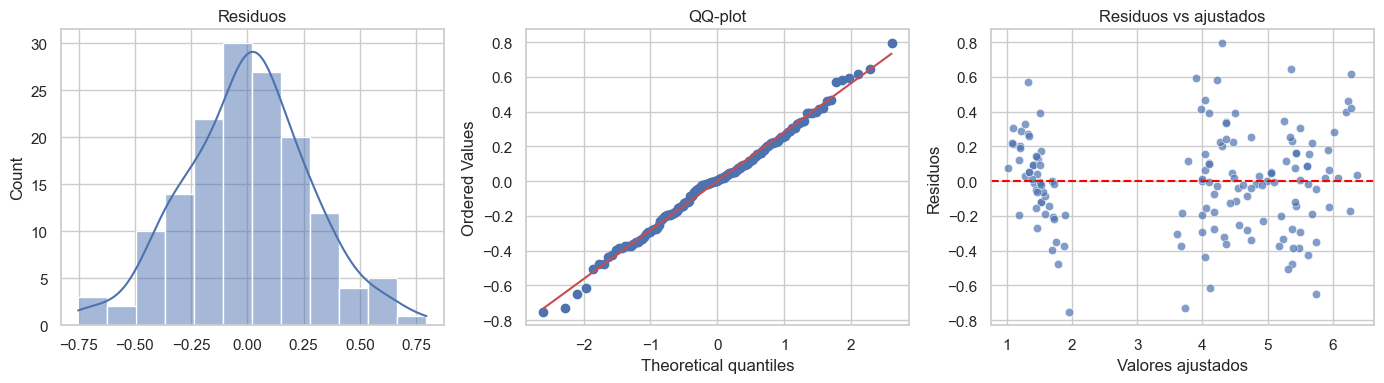

In [13]:
reg_lin = RegresionLineal(
    "petal_length ~ sepal_length + sepal_width + C(species)",
    df,
).ajustar()

print(reg_lin.resumen())
display(reg_lin.coeficientes())
display(reg_lin.bondad_ajuste())

reg_lin.grafico_regresion("sepal_length", "petal_length")
plt.show()

reg_lin.grafico_predichos_vs_observados()
plt.show()

reg_lin.diagnostico_residuos()
plt.show()

## 5) Regresion logistica

In [14]:
df["es_setosa"] = (df["species"] == "setosa").astype(int)

reg_log = RegresionLogistica(
    "es_setosa ~ sepal_length + petal_length",
    df,
).ajustar()

print(reg_log.resumen())
display(reg_log.coeficientes())
display(reg_log.bondad_ajuste())
display(reg_log.matriz_confusion_basica())

reg_log.curva_roc_aprox("petal_length")
plt.show()

LinAlgError: Singular matrix